# MNIST
## 10. Linear Regression

In [1]:
from infdsa_mnist import mnist_load_normalized, mnist_output, linear_regression, linear_regression_output
from infdsa_mnist.mnist_output import display_total_errors_barplot

In the previous chapter, as well as this one, we normalize the MNIST dataset before we even start working with it. This is because the features, in this case the 784 pixels of each image in the MNIST dataset, are between 0 and 255, and normalizing them to be between 0 and 1 helps contextualize the bounds of the data for the model. For example, if we use the raw data, the model would have to learn that the pixel values are between 0 and 255. If it doesn't, it cannot adjust the weights properly, and the model will not learn effectively. By normalizing the data, we are essentially telling the model that the pixel values are between 0 and 1, which the model can easily learn and adjust the weights accordingly. It also helps when we have several features with different scales, as it brings them to a common scale, which can improve the performance of the model. In the case of MNIST, since all pixel values are on the same scale, normalizing them helps the model learn more effectively and efficiently.

In [2]:
(train_data, test_data) = mnist_load_normalized.load_mnist_normalized()
x_train, y_train = train_data
x_test, y_test = test_data

x_train_flat = mnist_load_normalized.flatten_images(x_train)
x_test_flat = mnist_load_normalized.flatten_images(x_test)

In this chapter, we will implement linear regression to classify the MNIST dataset. Linear regression is a simple algorithm that models the relationship between several independent variables (features) and a dependent variable (target) by fitting a linear equation to the observed data. In the case of MNIST, we will use linear regression to predict the class of each image based on the pixel values. The model will learn to assign weights to each pixel, and these weights will be adjusted during training to minimize the error between the predicted and actual classes.

## Creating a Model

In [3]:
y_binary = linear_regression.make_binary_labels(y_train, digit=7)
model_7 = linear_regression.train_linear_model(x_train_flat, y_binary)

We have created a single linear regression model for the class '7.' This model is trained to predict the likelihood of an image belonging to class '7' based on the pixel values. The model will assign weights to each pixel, and these weights will be adjusted during training to minimize the error between the predicted and actual classes for images of '7.' It works like this: bright pixels in logical locations for the digit '7' will have higher weights, while background pixels or pixels irrelevant to the shape of '7' will have lower weights.

As we can see, the model is trained on a flattened version of the images (`x_train_flat`). It also requires us to have created `y_binary`. This is a modified version of the labels (`y_train`), where the labels belonging to class '7' are changed to '1' and all other labels are changed to '0.' This is because linear regression is designed to predict a binary outcome (0 or 1), and by creating binary labels, the context is made clear for the model.

The reason for creating a model for a single class instead of training a single model to handle all 10 classes is that linear regression is not designed for multi-class classification tasks. It is, instead, designed for regression tasks where the target variable is continuous. By creating separate models for each class, we can mimic the behavior of a multi-class classifier using linear regression. Each model will output a score that indicates how likely it is that an image belongs to its respective class, and we can use these scores to determine the predicted class for each image. This approach is called one-vs-rest (OvR) classification.

To put this in more perspective, let's say we have a single model that tries to predict all 10 classes at once. Linear regression would treat the labels as ordered, continuous values (0, 1, 2, ..., 9), which is not the case in a classification problem. It would consider 9 being closer to 8 than to 1. It would also consider the distance between 5 and 7 to be the same as the distance between 3 and 5. Neither example makes sense in a classification context, as these relationships do not exist for the classes in the way we want them to be treated. By creating separate models for each class, these relationships do not exist to the models, and they can focus on learning the features that are relevant for their respective class without the influence of the other classes. This allows the models to learn more effectively and make better predictions for their respective classes.

When we give the models an image, each model will output a confidence score that indicates how likely it is that the image belongs to a respective class. This is not a probability, but it can be used to determine the predicted class by selecting the model with the highest confidence score. For example, if we have an image of the digit '7,' the model for class '7' could output a confidence score of 0.8, while the other models might output lower scores. In this case, we would predict that the image belongs to class '7' because it has the highest confidence score among all the models. This approach allows us to use linear regression for multi-class classification tasks, even though it is not inherently designed for that purpose.

### Weights and Intercept
In linear regression, the model learns by adjusting two key components:
- **Weights**: These represent the importance of a particular feature (in our case, one of the 784 pixel values).
    - A _high weight_ means the pixel's brightness is strongly associated with the target digit (e.g., bright pixels following the shape of a '7').
    - A _low or negative weight_ means the pixel is either irrelevant background noise or actively indicates the image is not the target digit.
- **Intercept**: The baseline score for the model when all features are zero. While it doesn't translate into anything meaningful on its own, it allows the model to shift its predictions up or down to better fit the data given to it.

In [4]:
weights_7 = model_7.coef_
print(f"Shape of weights: {weights_7.shape}")
print(f"Model intercept: {model_7.intercept_}")

Shape of weights: (784,)
Model intercept: 0.14154055524316334


## Predicting with the Models

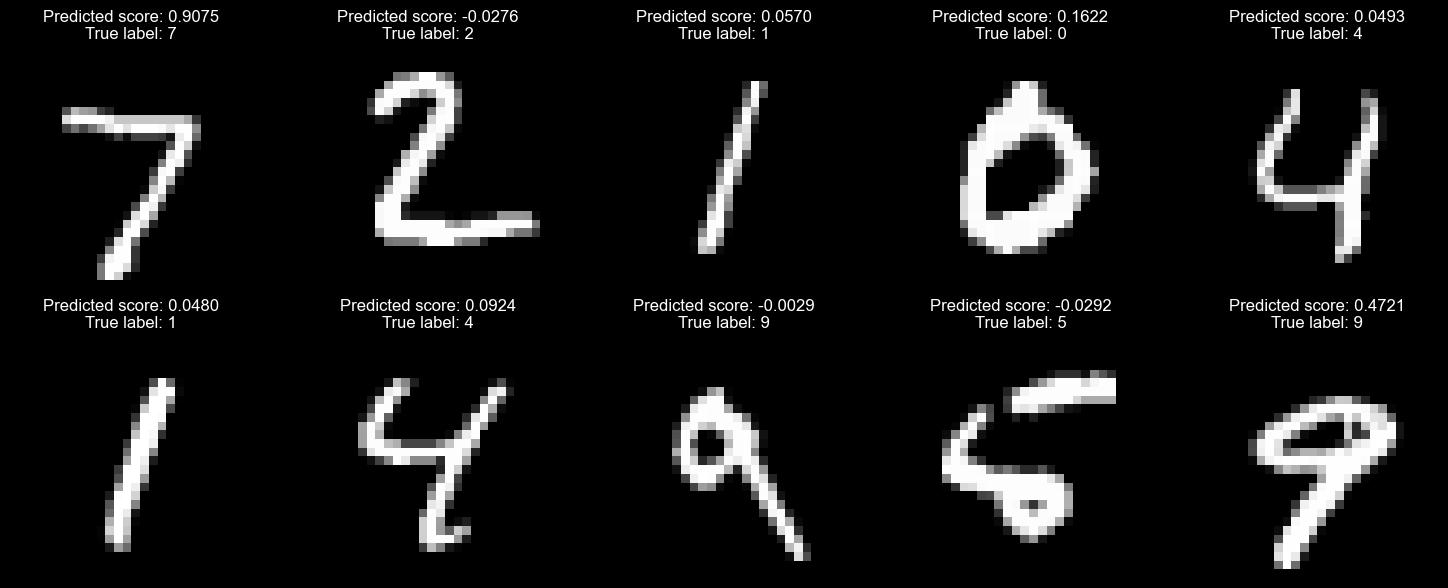

In [5]:
test_images = x_test_flat[:10]
test_labels = y_test[:10]

results = [(linear_regression.predict_num(model_7, image), label)
           for image, label in zip(test_images, test_labels)]

mnist_output.display_grid(
    x=[img.reshape(28, 28) for img in test_images],
    y=[f"Predicted score: {pred:.4f}\nTrue label: {true_label}" for pred, true_label in results],
    rows=2,
    cols=5
)

> Note: The assignment signature for `predict_num` includes a `digit` argument for printing the true label inside the function. We keep `predict_num` a pure function and handle the display of the true label when calling, as shown in the code above.

In the function, the `.predict()` inside `predict_num` returns an array of predictions, even if we are only predicting for a single image. This is because the `.predict()` method is designed to handle multiple samples at once, and it always returns an array of predictions, regardless of the sample number. We use `[0]` to extract the single prediction from the array when we are only predicting for one image. This makes it easier to work with the prediction, as we do not have to take the single value out of the array every time we need to use it.

Before we dive into analyzing the results, it is important to know how to read the output. The predicted scores are not strict probabilities. They are just confidence scores.
- **Score ~ 0**: The model is unsure whether an image belongs to the target class.
- **Score > 0**: The model is confident that the image belongs to the target class.
- **Score < 0**: The model is confident that the image is not the target class.

Most predictions of non-7 digits are either negative or hover around 0. However, the model shows an unusual confidence score of ~0.5 for the last '9' in the test subset. This is a bit surprising, as we would expect the model to be more confident that a '9' is not a '7.' However, looking at the '9' in question, we can make an educated guess that the confidence score is a result of how the digit is written. The angle is similar to that of '7,' and the hole in the '9' is wide but not very long. This likely triggered the high-weight pixels associated with '7' in the model, but is a little confused about the gap that does exist in the '9.'

## Predicting with All Models

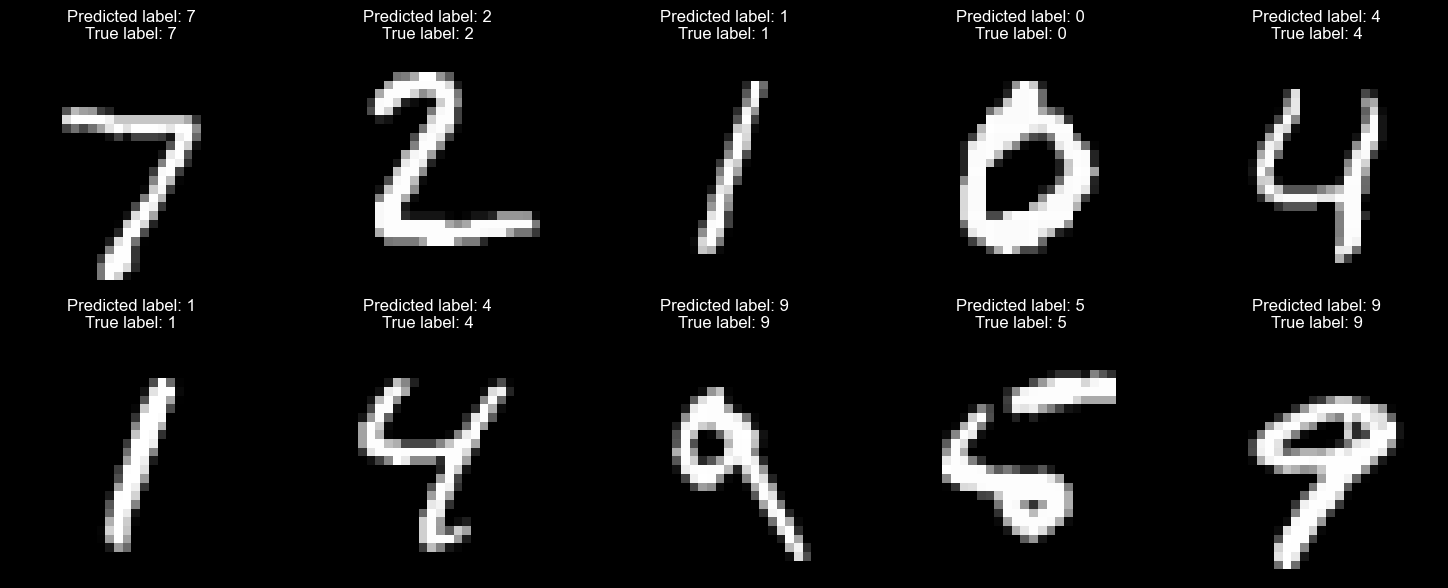

In [6]:
models = linear_regression.make_models(x_train_flat, y_train)

test_images = x_test_flat[:10]
test_labels = y_test[:10]

results = []
for image, label in zip(test_images, test_labels):
    results.append((linear_regression.predict_case(models, image), label))

mnist_output.display_grid(
    x=[img.reshape(28, 28) for img in test_images],
    y=[f"Predicted label: {pred}\nTrue label: {true_label}" for pred, true_label in results],
    rows=2,
    cols=5
)

Predictions with all models work like so:
- For each image, we calculate the confidence score for each model.
- We select the model with the highest confidence score. We do this to ensure the highest chance of matching the true label.
- We return the predicted label.

In our test with the first 10 images, we can see that the model correctly predicted all 10 images. This is a good sign. However, it is important to note that this is just a small sample of the test set, and we should evaluate the model on the entire test set to get a better understanding of its performance. The '9' that previously had a high confidence score for being a '7' is correctly classified as a '9' when we use all models. This shows the importance of using all models for making predictions in a multi-class classification task, especially when the models aren't technically designed for this express purpose.

## Custom Features
In the previous sections, we used all 784 pixel values as features for our linear regression models. However, since we have made features based on other properties of the images in chapter `07_decision_tree`, we can also use those features for our linear regression models. This is an interesting experiment to see how the model performs with custom features compared to using all pixel values. By using custom features, we can potentially reduce the dimensionality of the data and focus on the most relevant information for making predictions. This can lead to improved performance.

As a reminder, the features we will use are the following:
1. Average pixel intensity
2. Symmetry
3. Center point concentration
4. Digit aspect ratio
5. Top left quadrant
6. Top right quadrant
7. Bottom left quadrant
8. Bottom right quadrant


To get started, we will create a new function that encapsulated the `extract_features` function we created in `decision_tree`. We do this because we want to put batches of images into the function, which is not possible with the `extract_features` function. Note here that we use `x_train` instead of `x_flat` here, as `extract_features` expects a 2D array of pixels. Some features will want the 2D array whilst others want a 1D array. The features that want the 1D array will do that conversion themselves.

In [7]:
x_custom_train = linear_regression.extract_features(x_train)
x_custom_test = linear_regression.extract_features(x_test)

custom_models = linear_regression.make_models(x_custom_train, y_train)

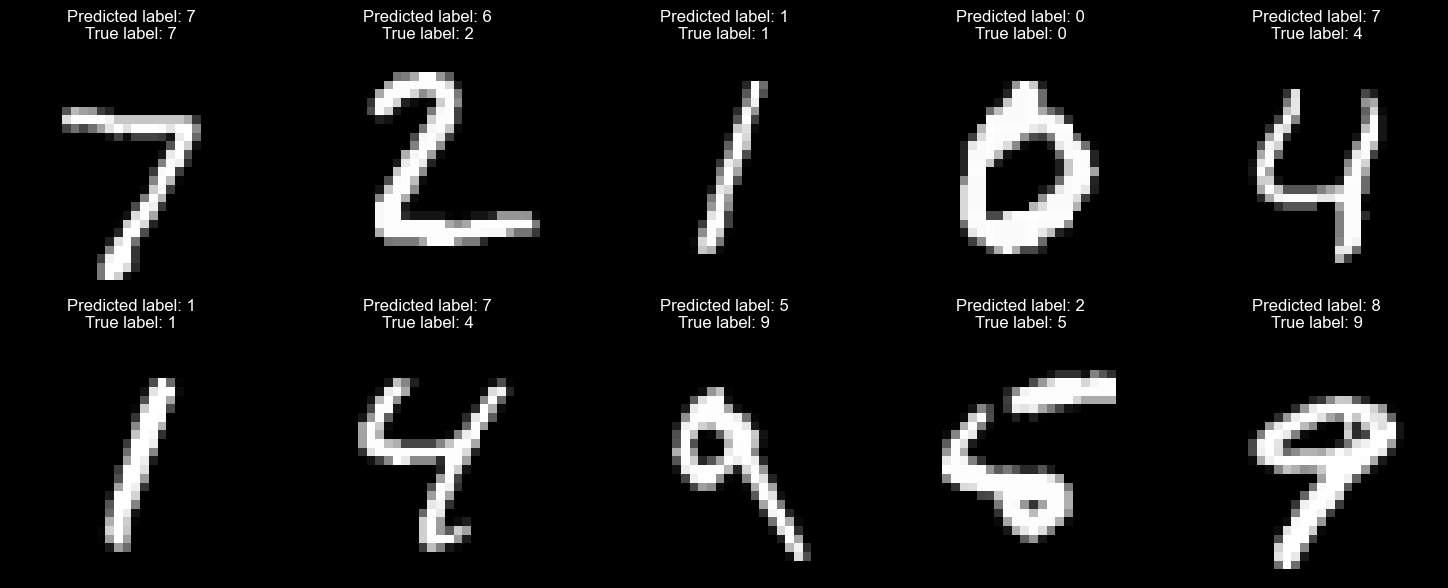

In [8]:
test_images = x_custom_test[:10]
test_labels = y_test[:10]

results = []
for image, label in zip(test_images, test_labels):
    results.append((linear_regression.predict_case(custom_models, image), label))

mnist_output.display_grid(
    x=[img.reshape(28, 28) for img in x_test[:10]],
    y=[f"Predicted label: {pred}\nTrue label: {true_label}" for pred, true_label in results],
    rows=2,
    cols=5
)

In this experiment, we have grabbed the features we created in the `07_decision_tree` chapter and used them to train linear regression models. Though the performance of the models is not incredible, it is still respectable, considering we are only using 8 features total. It is even more impressive when we consider the features we created were not created to mathematical perfection, but rather to be easily understood by a human. The negative impact of using custom features is the least felt on the '1's, which makes sense, as they are the most distinct and simple digits in the dataset.

While the performance of the model using custom features is not impressive, we have shown that it is possible to use custom features. The performance would likely be improved with a higher quantity of higher quality features.

Before we evaluate the models on the entire test set, we would like to add a third Linear Regression model to the mix. This model will be trained using both the pixel values and the custom features. This will allow us to see if there is any improvement in performance when we combine the two sets of features. We will concatenate the pixel values and the custom features to create a new feature set for this model. This will give us a better understanding of how the combination of features impacts the performance of the model.

In [9]:
x_combined_train = linear_regression.combine_features(x_train_flat, x_custom_train)
x_combined_test = linear_regression.combine_features(x_test_flat, x_custom_test)

combined_models = linear_regression.make_models(x_combined_train, y_train)

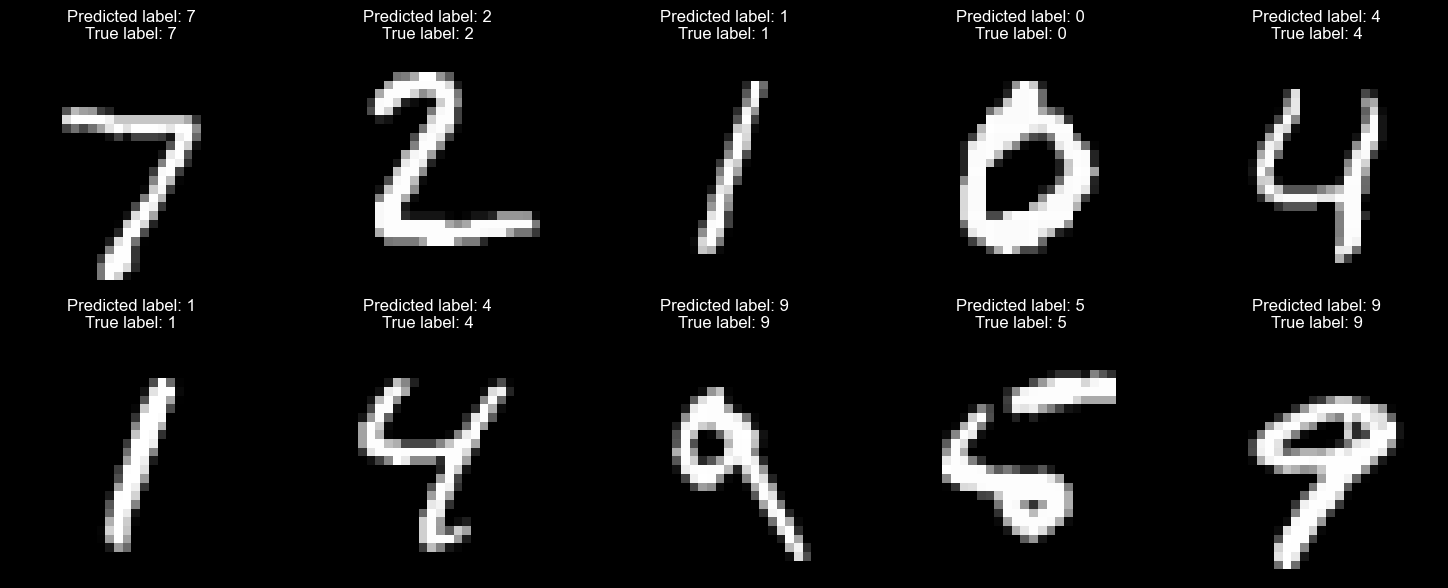

In [10]:
test_images = x_combined_test[:10]
test_labels = y_test[:10]

results = []
for image, label in zip(test_images, test_labels):
    results.append((linear_regression.predict_case(combined_models, image), label))

mnist_output.display_grid(
    x=[img.reshape(28, 28) for img in x_test[:10]],
    y=[f"Predicted label: {pred}\nTrue label: {true_label}" for pred, true_label in results],
    rows=2,
    cols=5
)

Interestingly, the test with the first 10 images shows that the combined model performs the exact same as the model using all pixel values. We had expected the combined model to perform a little worse, as we had thought the custom features would add some noise to the model. However, it seems that the custom features did not have a negative impact on the model's performance.

To fully evaluate the performance of the models, we will have to zoom out and evaluate them on the entire test set. This will give us a better understanding of how the models perform in general, rather than just on a small subset of the data.

## Benchmarking the Models

In [11]:
cases = [
    ("All Pixel Values", models, x_test_flat, y_test),
    ("Custom Features", custom_models, x_custom_test, y_test),
    ("Combined Features", combined_models, x_combined_test, y_test),
]

results = []
for (name, models_to_predict, x, y) in cases:
    predictions = linear_regression.predict_cases(models_to_predict, x)
    cm = linear_regression.create_confusion_matrix(y, predictions)
    accuracy = linear_regression.calculate_accuracy(y, predictions)
    results.append((name, cm, accuracy))

===== Linear Regression Metrics =====
Accuracy: 86.03%


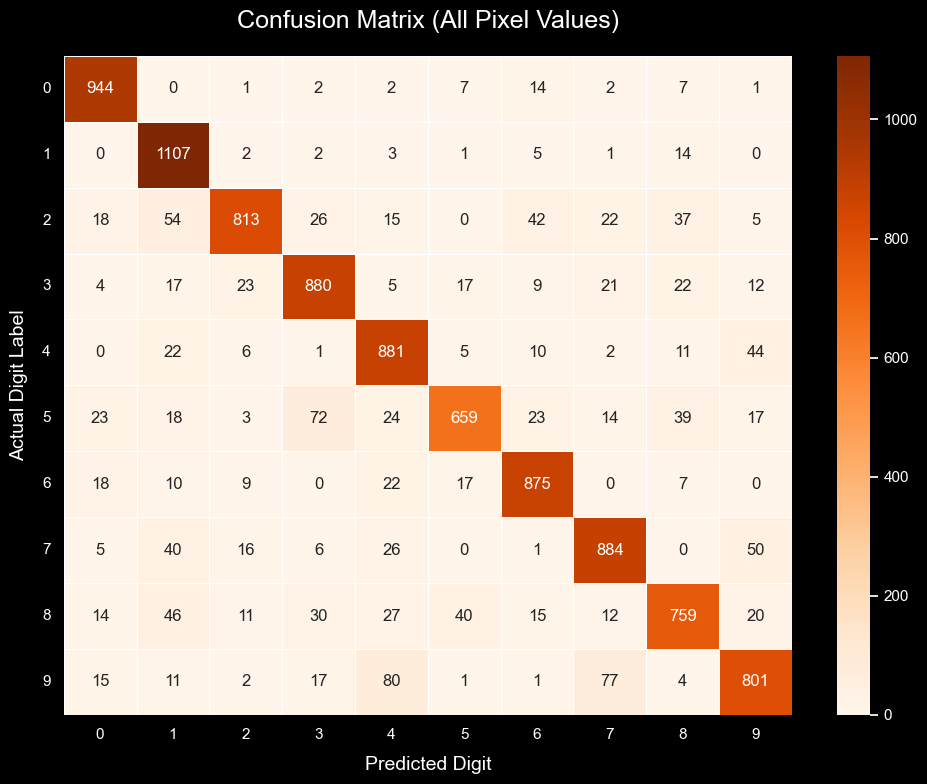

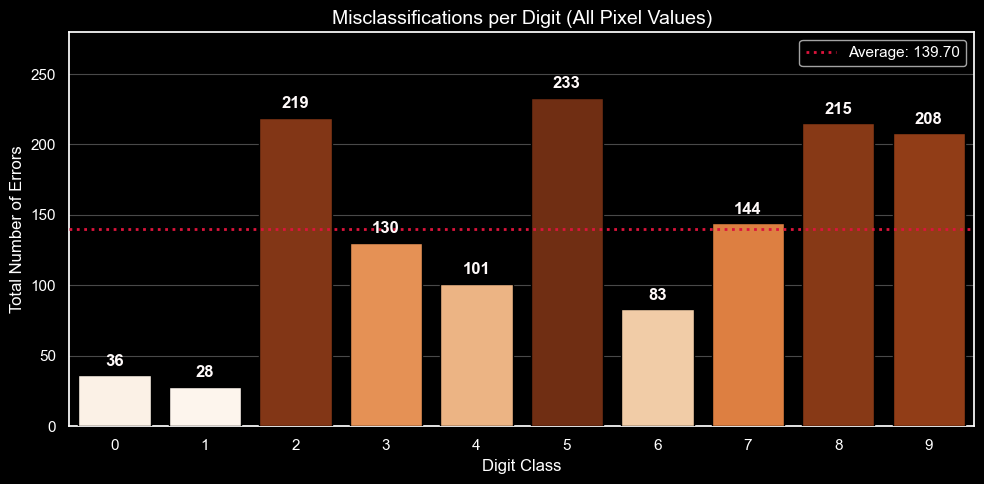



===== Linear Regression Metrics =====
Accuracy: 51.61%


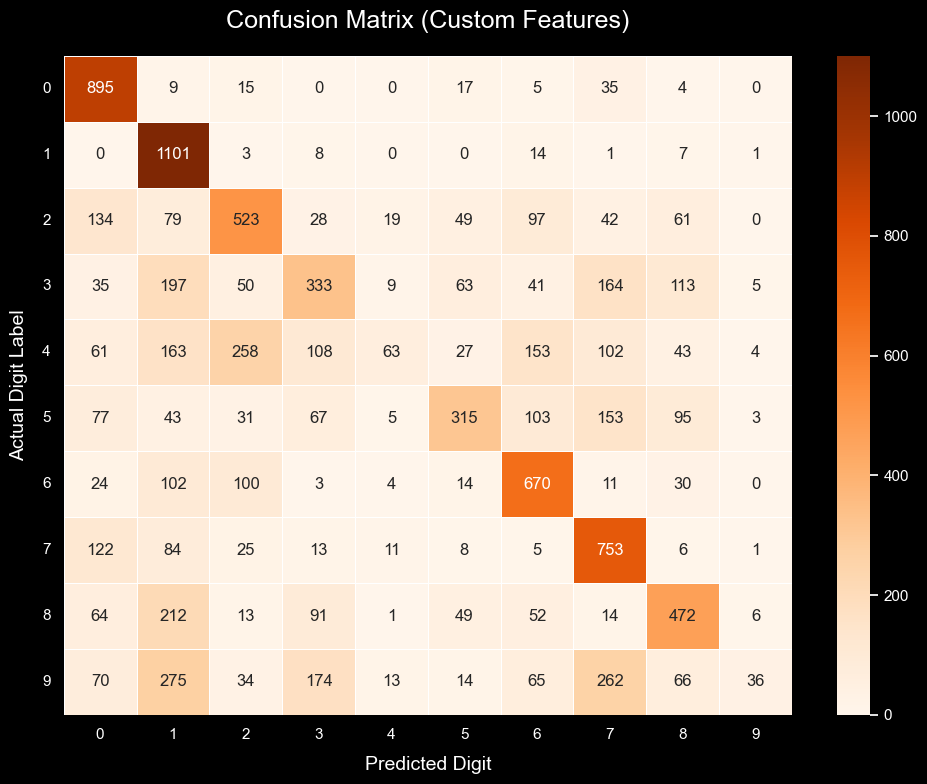

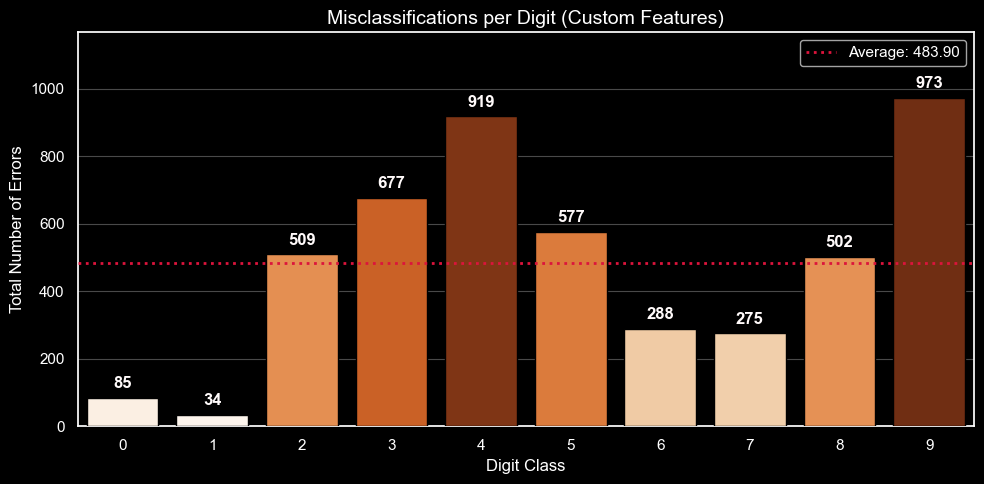



===== Linear Regression Metrics =====
Accuracy: 87.20%


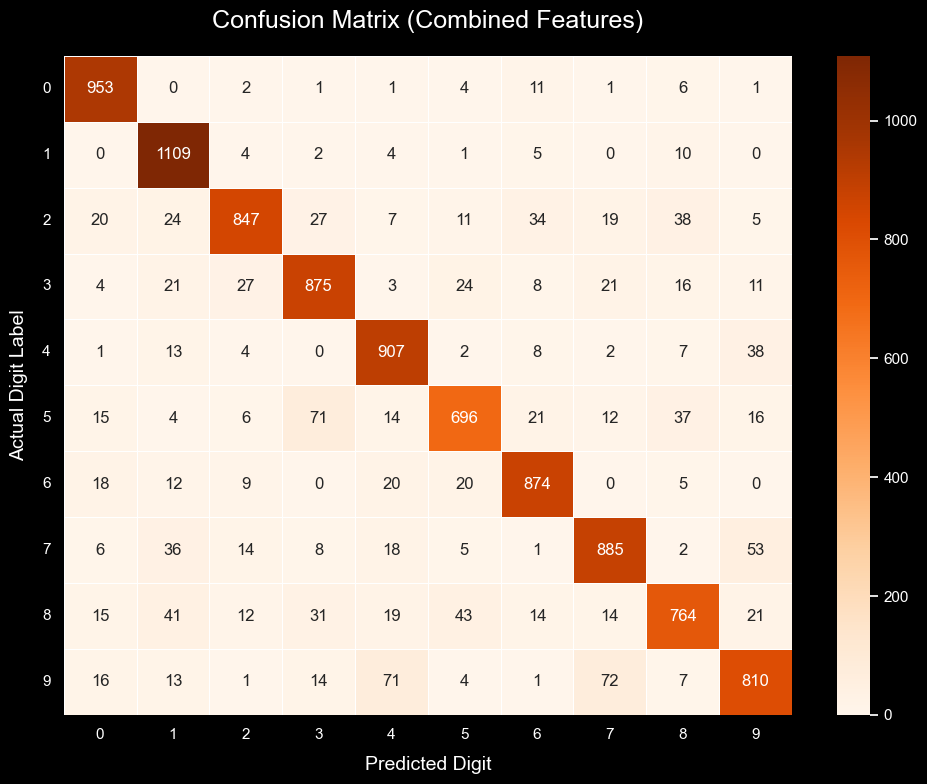

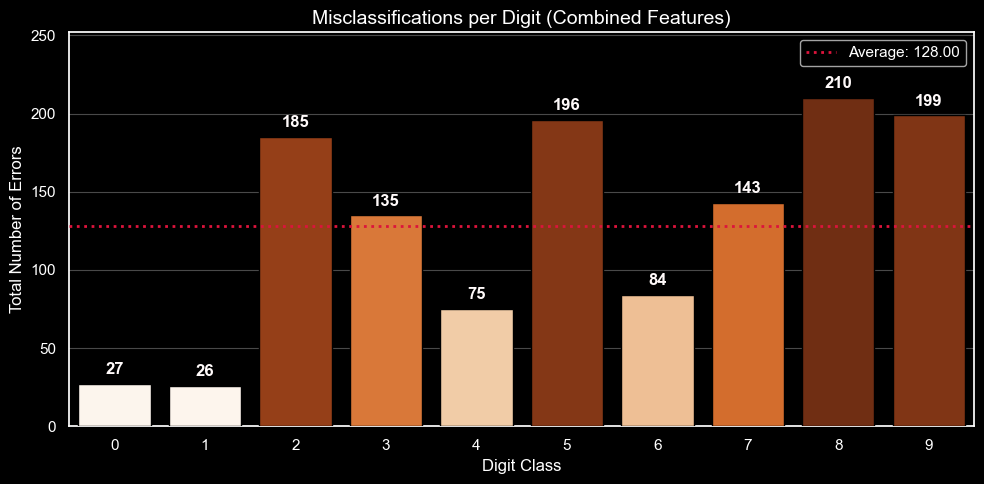

In [12]:
for name, cm, accuracy in results:
    linear_regression_output.display_metrics(cm, accuracy)
    linear_regression_output.display_full_confusion_matrix(cm, title=f"Confusion Matrix ({name})")
    display_total_errors_barplot(cm, title=f"Misclassifications per Digit ({name})")
    print("\n")

After evaluating the models on the entire test set, we can clearly see the impact of our feature selection:
- **All Pixel Values (Linear Regression):** ~86.03% accuracy

  A respectable score, though it is significantly lower than the perfect score we saw earlier when we only tested on 10 images. This highlights the importance of evaluating models on a larger test set to get a more accurate understanding of their performance.

- **Custom Features (Linear Regression):** ~51.61% accuracy

    A significant drop in performance compared to the baseline model. Since we condensed the 784 features down to just 8 features that were easy to grasp for humans, we have lost significant nuance in the model. The accuracy is in line with the performance we saw these features achieve in the `07_decision_tree` chapter.

- **Combined Features (Linear Regression):** ~87.20% accuracy

    A slight improvement over the model using all pixel values. The custom features did not have a significant impact on the model's performance. However, it did positively affect the performance ever so slightly to be an improvement across the board, except for digits '3' and '6,' which are ever so slightly worse than the baseline model.

- **K-Means Clustering (Unsupervised):** ~95.27% accuracy (taken from `09_k_means_clustering`)

    Surprisingly, our unsupervised K-Means Clustering model (using 130 prototypes per digit class) outperformed our supervised Linear Regression models.

Takeaway:
- Using custom features allows the model to learn something, but would require a higher quantity and quality of features to be competitive with the baseline model using all pixel values.
- A well-tuned unsupervised model can beat a supervised model when the supervised model does not have enough to work with.